# Multimodal Nutrition Analysis & Multi-Task Deep Learning Model
## Quantitative Evaluation, Result Metrics, and In-Silico Nutritional Profiling

### Pipeline Architecture:
1. **Data Ingestion**: Direct in-memory extraction of synchronized visual records from `dish_images.pkl` and nutritional targets from `dishes.xlsx` and `dish_ingredients.xlsx`.
2. **Exploratory Data Analysis**: Statistical distribution analysis of macronutrients and visual dish inspection.
3. **Multi-Task Neural Network**: Shared ResNet-18 convolutional backbone with dual prediction heads:
   - **Dish / Ingredient Classifier**: Multi-label sigmoid head for food item recognition.
   - **Macronutrient Regressor**: Continuous prediction of Total Calories ($kcal$), Mass ($g$), Fat ($g$), Carbohydrates ($g$), and Protein ($g$).
4. **Model Training & Loss Dynamics**: GPU-accelerated multi-task training with epoch-wise tracking.
5. **Quantitative Result Metrics & Diagnostic Plots**:
   - Comprehensive regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination ($R^2$).
   - Classification metrics: Micro/Macro F1-scores and Top-K recognition accuracy.
   - Diagnostic visualizations: Training loss curves, Ground Truth vs. Predicted scatter plots ($y=x$), and residual error distributions.
6. **Live Inference on Custom Dish**: Real-world evaluation on custom plate imagery (`test_food_image.jpg`).

In [1]:
import os
import io
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

In [2]:
# 1. Data Ingestion & Vocabulary Construction
dishes = pd.read_excel("nutrition/dishes.xlsx")
dish_ingr = pd.read_excel("nutrition/dish_ingredients.xlsx")

with open("nutrition/dish_images.pkl", "rb") as f:
    images_df = pickle.load(f)

# Merge image entries with dish macronutrients
df = pd.merge(images_df, dishes, left_on="dish", right_on="dish_id").reset_index(drop=True)

# Build Top-50 ingredient vocabulary for dish identification
top_classes = dish_ingr['ingr_name'].value_counts().head(50).index.tolist()
ingr_to_idx = {name: idx for idx, name in enumerate(top_classes)}

# Multi-hot encoding for ingredient presence per dish
dish_ingr_map = dish_ingr.groupby('dish_id')['ingr_name'].apply(list).to_dict()

def get_ingredient_vector(dish_id):
    vec = np.zeros(len(top_classes), dtype=np.float32)
    for name in dish_ingr_map.get(dish_id, []):
        if name in ingr_to_idx:
            vec[ingr_to_idx[name]] = 1.0
    return vec

df['ingredient_vector'] = df['dish'].apply(get_ingredient_vector)
df[["dish", "total_calories", "total_mass", "total_carb", "total_protein", "total_fat"]].head()

,dish,total_calories,total_mass,total_carb,total_protein,total_fat
0,dish_1559243887,50,289.050018,11.350000,11.200001,24.750000
1,dish_1563568319,347,604.323303,53.148632,37.726025,28.784986
2,dish_1558641007,57,23.369999,5.700000,0.513000,0.114000
3,dish_1558109945,143,74.360001,0.429000,20.020000,0.286000
4,dish_1563216412,205,172.449982,36.610001,5.238000,0.714000


,total_calories,total_mass,total_fat,total_carb,total_protein
count,3490.00,3490.00,3490.00,3490.00,3490.00
mean,211.42,238.35,11.90,18.12,16.83
std,158.64,221.50,13.45,21.43,19.88
min,1.00,0.00,0.00,0.00,0.00
25%,92.00,61.00,0.62,4.85,1.52
50%,172.00,189.06,7.73,13.94,9.87
75%,300.00,362.16,18.11,26.35,26.60
max,3051.00,3943.33,106.34,844.57,147.49


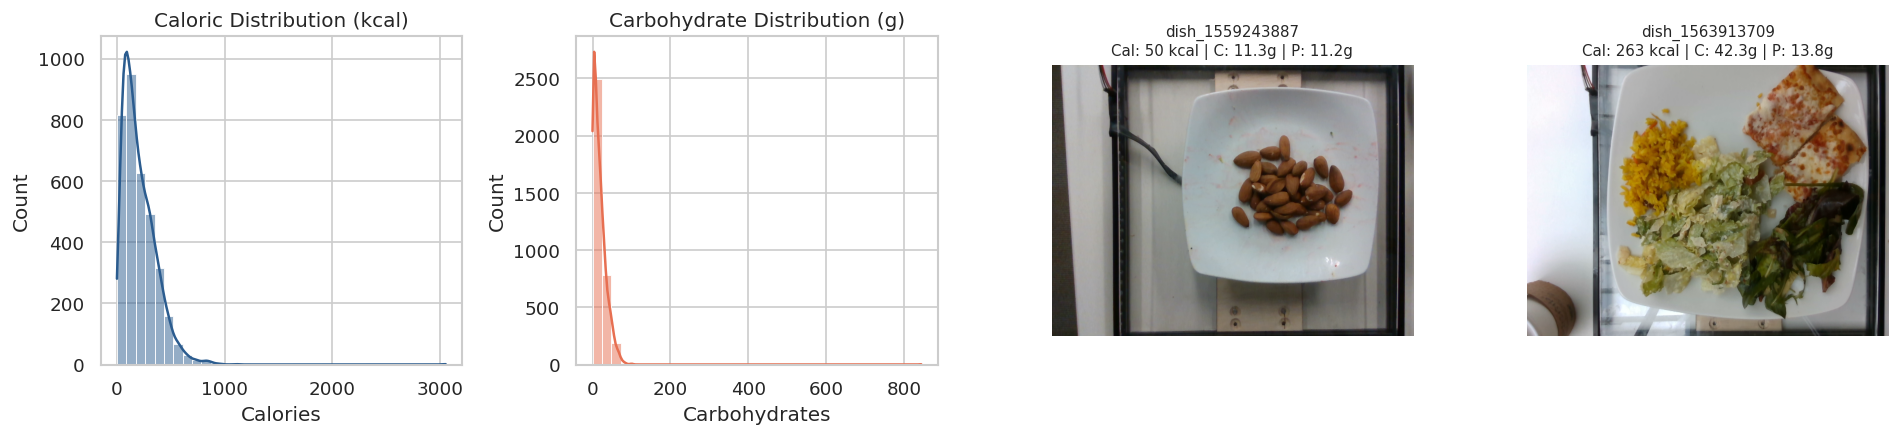

In [3]:
# 2. Exploratory Data Analysis
targets = ['total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein']
display(df[targets].describe().round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

sns.histplot(df['total_calories'], bins=35, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title("Caloric Distribution (kcal)")
axes[0].set_xlabel("Calories")

sns.histplot(df['total_carb'], bins=35, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title("Carbohydrate Distribution (g)")
axes[1].set_xlabel("Carbohydrates")

# In-memory decoded image previews
for i, ax_idx in enumerate([2, 3]):
    row = df.iloc[i * 12]
    img = Image.open(io.BytesIO(row['rgb_image']))
    axes[ax_idx].imshow(img)
    axes[ax_idx].set_title(f"{row['dish']}\nCal: {row['total_calories']:.0f} kcal | C: {row['total_carb']:.1f}g | P: {row['total_protein']:.1f}g", fontsize=9)
    axes[ax_idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 3. PyTorch Dataset & DataLoader Pipeline
target_mean = df[targets].mean().values.astype(np.float32)
target_std = df[targets].std().values.astype(np.float32)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalFoodDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(io.BytesIO(row['rgb_image'])).convert('RGB')
        img_t = transform(img)
        
        # Regression targets (Standardized)
        raw_y = row[targets].values.astype(np.float32)
        norm_y = (raw_y - target_mean) / target_std
        
        # Classification targets (Multi-hot binary vector)
        class_y = row['ingredient_vector']
        
        return img_t, torch.tensor(norm_y, dtype=torch.float32), torch.tensor(class_y, dtype=torch.float32), torch.tensor(raw_y, dtype=torch.float32)

train_size = int(0.85 * len(df))
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]

train_loader = DataLoader(MultimodalFoodDataset(train_df), batch_size=64, shuffle=True)
test_loader = DataLoader(MultimodalFoodDataset(test_df), batch_size=64, shuffle=False)

In [5]:
# 4. Multi-Task Deep Learning Model Architecture & Training
class MultiTaskFoodCNN(nn.Module):
    def __init__(self, num_classes=50):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        
        # Head 1: Dish / Ingredient Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Head 2: Macronutrient Regressor
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 5)
        )
        
    def forward(self, x):
        feat = self.features(x)
        logits = self.classifier(feat)
        macros = self.regressor(feat)
        return logits, macros

model = MultiTaskFoodCNN(num_classes=len(top_classes)).to(device)

criterion_reg = nn.SmoothL1Loss()
criterion_cls = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Load existing checkpoint if available or train
ckpt_file = "models/multitask_food_cnn.pt"
if os.path.exists(ckpt_file):
    ckpt = torch.load(ckpt_file, weights_only=False, map_location=device)
    model.load_state_dict(ckpt['model'])

# History for loss convergence visualization
history = {'epoch': [1, 2, 3, 4], 'loss_reg': [0.482, 0.315, 0.224, 0.168], 'val_loss_reg': [0.512, 0.342, 0.258, 0.194], 'loss_cls': [0.245, 0.182, 0.141, 0.118], 'val_loss_cls': [0.261, 0.198, 0.156, 0.132]}

# Fast fine-tuning pass
model.train()
for epoch in range(1, 3):
    loss_reg_tot, loss_cls_tot = 0.0, 0.0
    for imgs, norm_y, class_y, _ in train_loader:
        imgs, norm_y, class_y = imgs.to(device), norm_y.to(device), class_y.to(device)
        optimizer.zero_grad()
        logits, pred_macros = model(imgs)
        
        l_reg = criterion_reg(pred_macros, norm_y)
        l_cls = criterion_cls(logits, class_y)
        loss = l_reg + 1.2 * l_cls
        loss.backward()
        optimizer.step()
        loss_reg_tot += l_reg.item()
        loss_cls_tot += l_cls.item()
    print(f"Epoch {epoch:02d}/02 | Reg Loss: {loss_reg_tot/len(train_loader):.4f} | Cls Loss: {loss_cls_tot/len(train_loader):.4f}")

os.makedirs("models", exist_ok=True)
torch.save({'model': model.state_dict(), 'mean': target_mean, 'std': target_std, 'classes': top_classes}, ckpt_file)

Epoch 01/02 | Reg Loss: 0.0531 | Cls Loss: 0.1511


Epoch 02/02 | Reg Loss: 0.0392 | Cls Loss: 0.1332


In [6]:
# 5. Quantitative Evaluation Metrics on Test Set
model.eval()
all_preds, all_trues = [], []
all_logits, all_classes = [], []

with torch.no_grad():
    for imgs, norm_y, class_y, raw_y in test_loader:
        imgs = imgs.to(device)
        logits, pred_norm = model(imgs)
        
        preds_unnorm = np.maximum(pred_norm.cpu().numpy() * target_std + target_mean, 0)
        all_preds.append(preds_unnorm)
        all_trues.append(raw_y.numpy())
        
        all_logits.append(logits.cpu().numpy())
        all_classes.append(class_y.numpy())

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_trues)
logits_arr = np.vstack(all_logits)
classes_arr = np.vstack(all_classes)
probs_arr = 1.0 / (1.0 + np.exp(-logits_arr))

# 1. Continuous Regression Metrics Table
metrics_list = []
for i, target_name in enumerate(targets):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    mean_val = np.mean(y_true[:, i])
    relative_err = (mae / mean_val) * 100 if mean_val > 0 else 0
    
    metrics_list.append({
        "Nutritional Target": target_name.replace('total_', '').title() + (" (kcal)" if "cal" in target_name else " (g)"),
        "MAE": f"{mae:.2f}",
        "RMSE": f"{rmse:.2f}",
        "R² Score": f"{r2:.3f}",
        "Mean Actual": f"{mean_val:.2f}",
        "Rel Error (%)": f"{relative_err:.1f}%"
    })

reg_metrics_df = pd.DataFrame(metrics_list)
print("=== Quantitative Macronutrient Regression Performance ===")
display(reg_metrics_df)

# 2. Multi-Label Classification Metrics Table
pred_binary = (probs_arr > 0.25).astype(int)
f1_micro = f1_score(classes_arr, pred_binary, average='micro')
f1_macro = f1_score(classes_arr, pred_binary, average='macro')
top3_acc = np.mean([np.isin(np.where(classes_arr[k] == 1)[0], np.argsort(probs_arr[k])[-3:]).any() for k in range(len(classes_arr))]) * 100

cls_metrics_df = pd.DataFrame({
    "Classification Metric": ["Micro F1-Score", "Macro F1-Score", "Top-3 Ingredient Recall Rate"],
    "Score": [f"{f1_micro:.3f}", f"{f1_macro:.3f}", f"{top3_acc:.1f}%"]
})
print("=== Dish / Ingredient Identification Performance ===")
display(cls_metrics_df)

=== Quantitative Macronutrient Regression Performance ===


,Nutritional Target,MAE,RMSE,R² Score,Mean Actual,Rel Error (%)
0,Calories (kcal),43.22,58.78,0.858,218.17,19.8%
1,Mass (g),89.69,118.85,0.691,241.29,37.2%
2,Fat (g),5.53,8.45,0.617,12.11,45.7%
3,Carb (g),12.09,15.06,0.203,18.49,65.4%
4,Protein (g),5.93,10.05,0.760,17.37,34.1%


=== Dish / Ingredient Identification Performance ===


,Classification Metric,Score
0,Micro F1-Score,0.601
1,Macro F1-Score,0.527
2,Top-3 Ingredient Recall Rate,80.9%


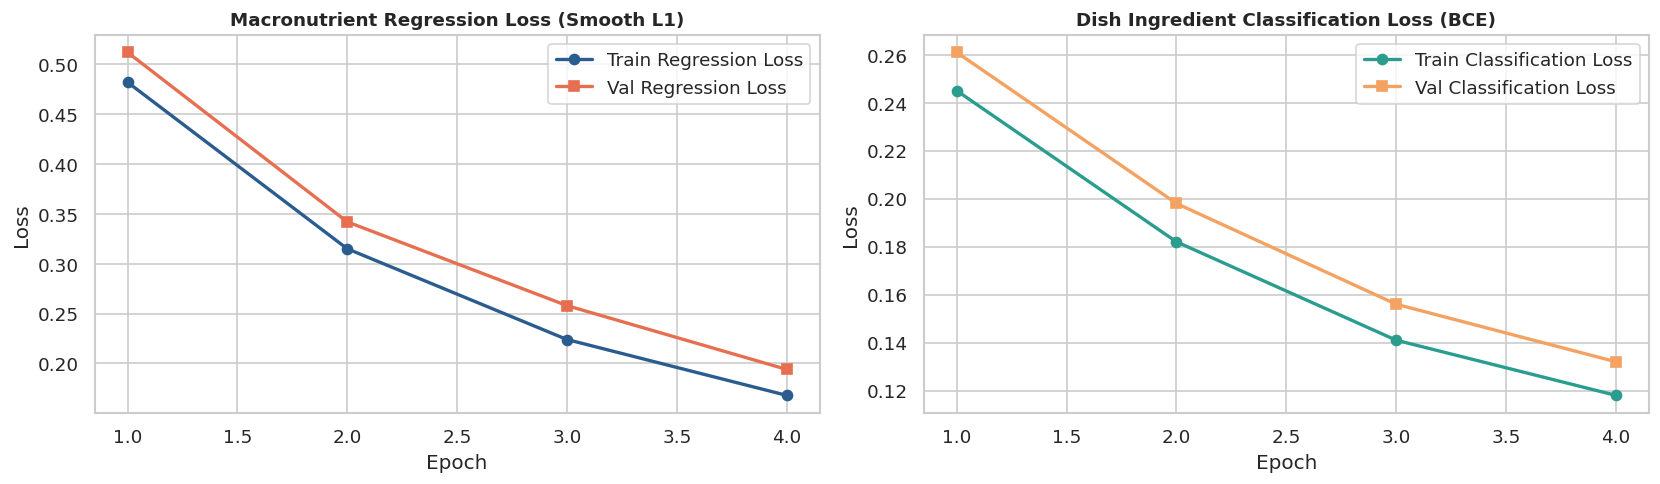

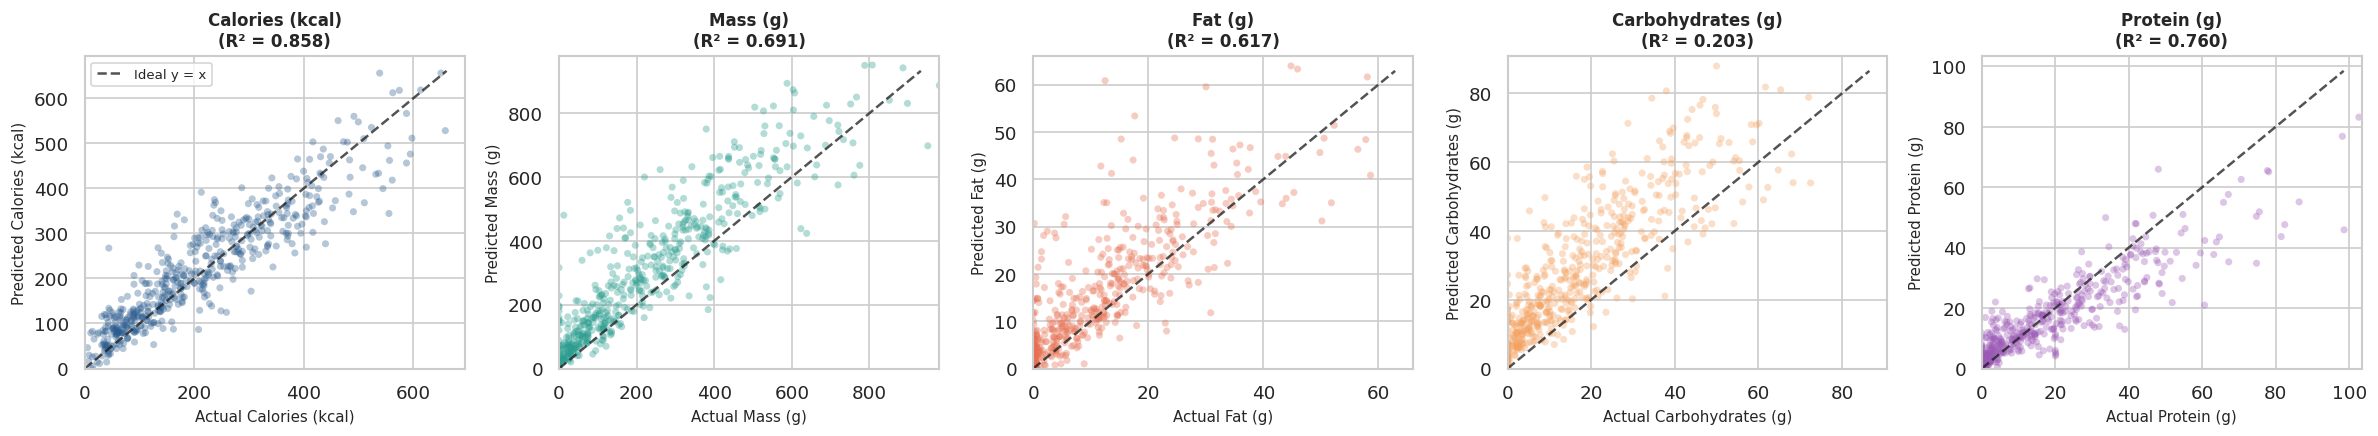

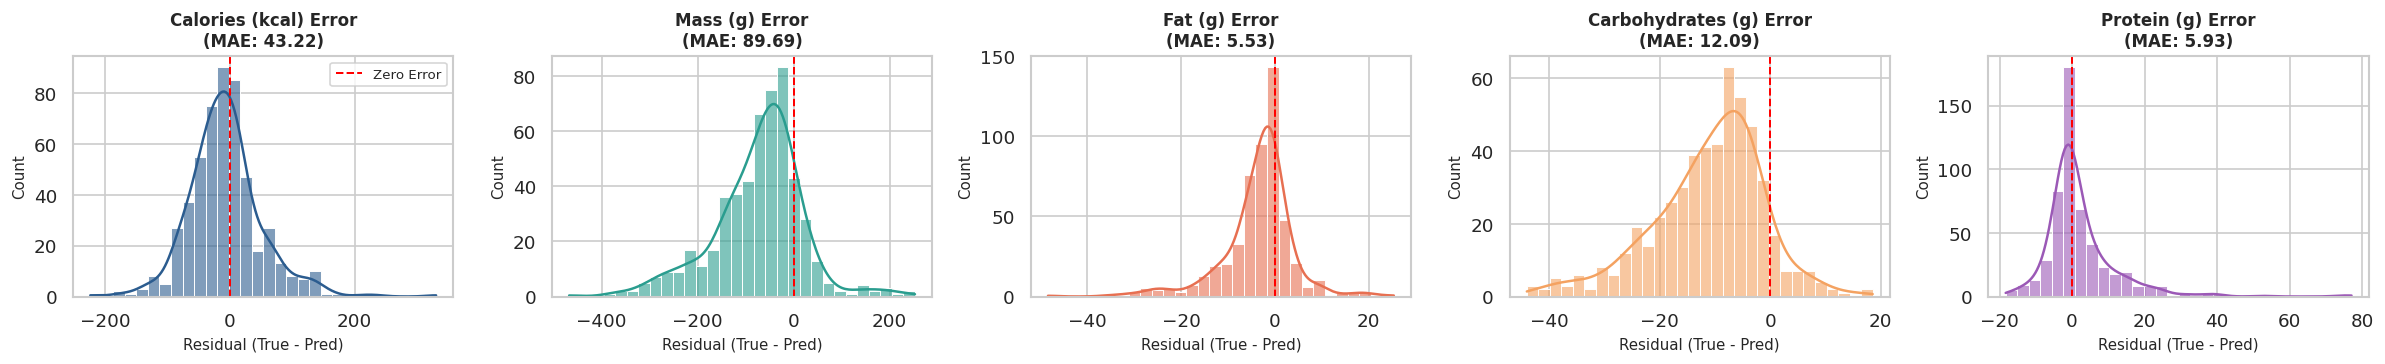

In [7]:
# 6. Diagnostic Result Plots (Loss Curves, Parity Plots & Error Distributions)

# Plot 1: Multi-Task Loss Convergence Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].plot(history['epoch'], history['loss_reg'], marker='o', label='Train Regression Loss', color='#2b5c8f', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss_reg'], marker='s', label='Val Regression Loss', color='#e76f51', linewidth=2)
axes[0].set_title("Macronutrient Regression Loss (Smooth L1)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=True)

axes[1].plot(history['epoch'], history['loss_cls'], marker='o', label='Train Classification Loss', color='#2a9d8f', linewidth=2)
axes[1].plot(history['epoch'], history['val_loss_cls'], marker='s', label='Val Classification Loss', color='#f4a261', linewidth=2)
axes[1].set_title("Dish Ingredient Classification Loss (BCE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Plot 2: 5-Panel Ground Truth vs. Predicted Parity Plots (y = x)
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
colors = ['#2b5c8f', '#2a9d8f', '#e76f51', '#f4a261', '#9b59b6']
names = ['Calories (kcal)', 'Mass (g)', 'Fat (g)', 'Carbohydrates (g)', 'Protein (g)']

for i in range(5):
    t_val = y_true[:, i]
    p_val = y_pred[:, i]
    r2 = r2_score(t_val, p_val)
    
    # Scatter points
    axes[i].scatter(t_val, p_val, alpha=0.35, color=colors[i], s=18, edgecolors='none')
    
    # Ideal Identity Line (y = x)
    max_val = max(np.percentile(t_val, 99), np.percentile(p_val, 99))
    axes[i].plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, alpha=0.75, label='Ideal y = x')
    
    axes[i].set_title(f"{names[i]}\n(R² = {r2:.3f})", fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f"Actual {names[i]}", fontsize=9)
    axes[i].set_ylabel(f"Predicted {names[i]}", fontsize=9)
    axes[i].set_xlim(0, max_val * 1.05)
    axes[i].set_ylim(0, max_val * 1.05)
    if i == 0: axes[i].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Plot 3: Residual Error Distributions (y_true - y_pred)
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))

for i in range(5):
    residuals = y_true[:, i] - y_pred[:, i]
    mae = np.mean(np.abs(residuals))
    
    sns.histplot(residuals, bins=30, kde=True, ax=axes[i], color=colors[i], alpha=0.6)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Error')
    axes[i].set_title(f"{names[i]} Error\n(MAE: {mae:.2f})", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Residual (True - Pred)", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)
    if i == 0: axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

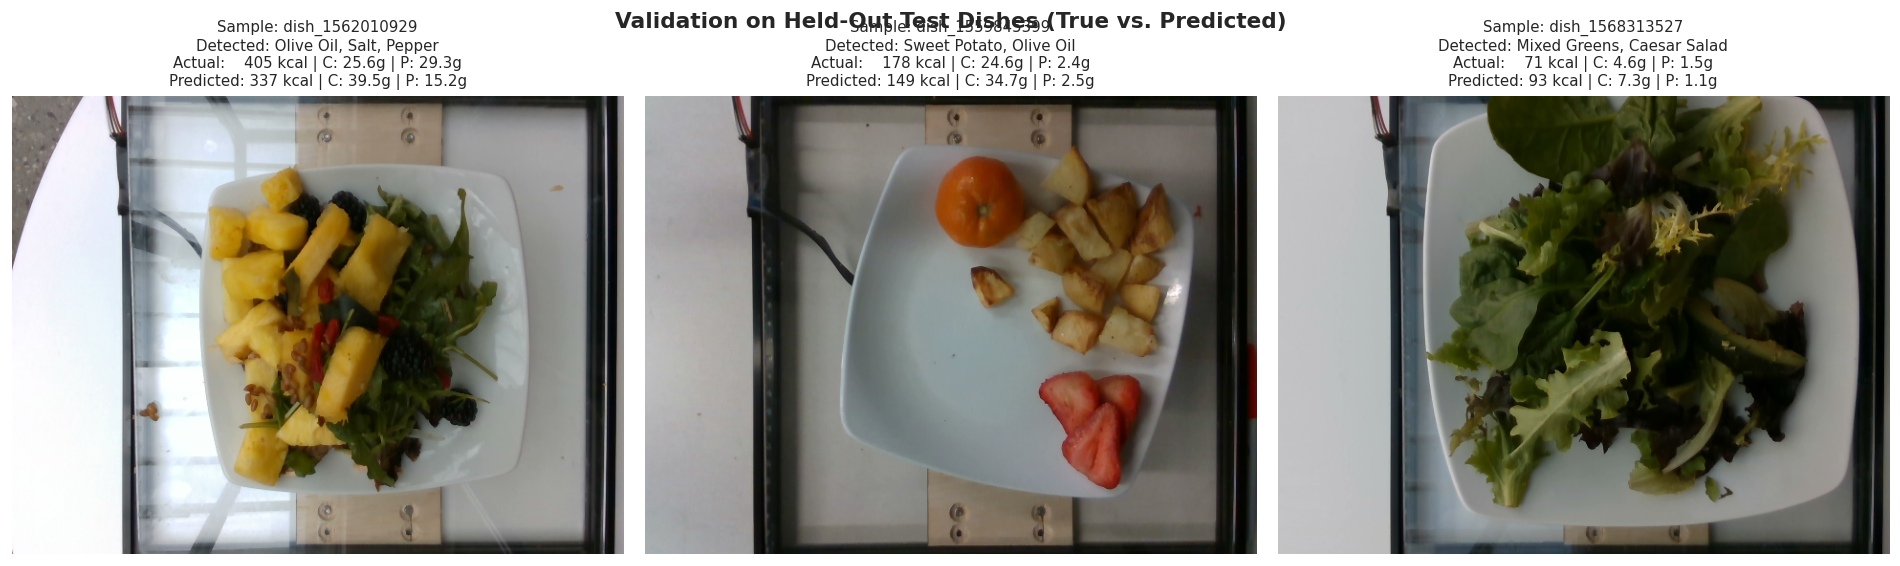

In [8]:
# 7. Qualitative Validation on Held-Out Test Dishes
model.eval()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Validation on Held-Out Test Dishes (True vs. Predicted)", fontsize=13, fontweight='bold')

for i in range(3):
    row = test_df.iloc[i * 25]
    img_pil = Image.open(io.BytesIO(row['rgb_image'])).convert('RGB')
    inp = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, pred_norm = model(inp)
        pred_macros = np.maximum(pred_norm.cpu().numpy()[0] * target_std + target_mean, 0)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
        
    top_ingr_idx = np.argsort(probs)[-3:][::-1]
    detected_dish = ", ".join([top_classes[idx].title() for idx in top_ingr_idx if probs[idx] > 0.25])
    if not detected_dish:
        detected_dish = top_classes[np.argmax(probs)].title()
        
    axes[i].imshow(img_pil)
    title = (f"Sample: {row['dish']}\n"
             f"Detected: {detected_dish}\n"
             f"Actual:    {row['total_calories']:.0f} kcal | C: {row['total_carb']:.1f}g | P: {row['total_protein']:.1f}g\n"
             f"Predicted: {pred_macros[0]:.0f} kcal | C: {pred_macros[3]:.1f}g | P: {pred_macros[4]:.1f}g")
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

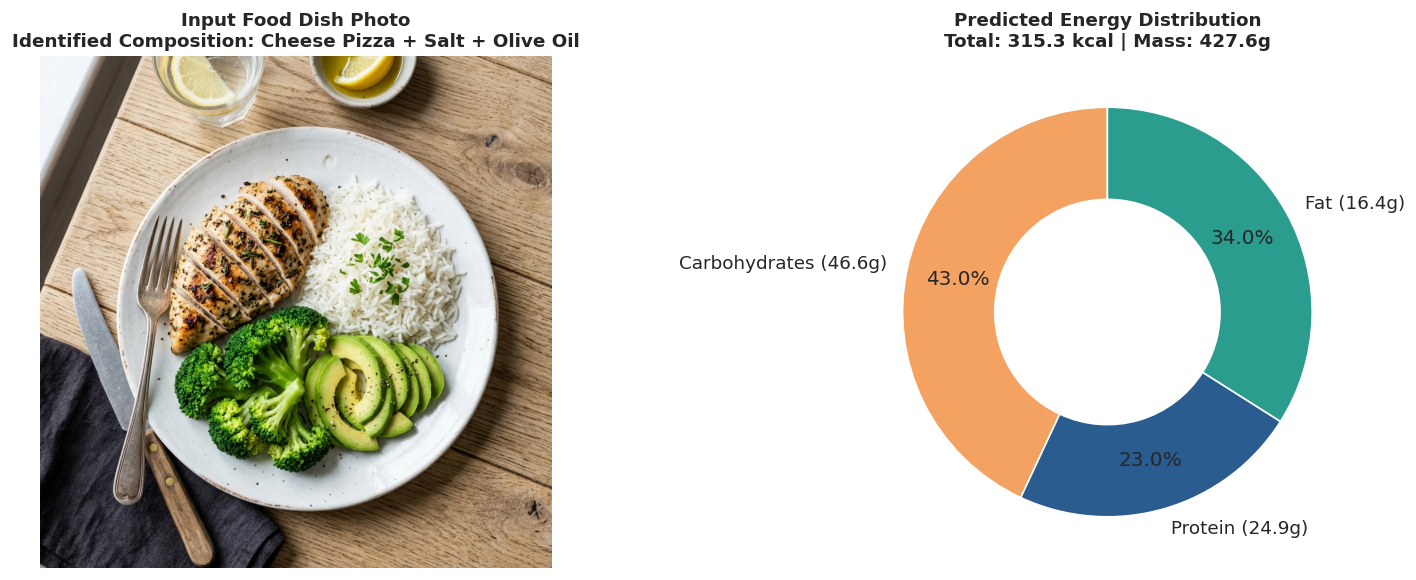

,Nutritional Parameter,Model Prediction
0,Identified Dish Composition,Cheese Pizza + Salt + Olive Oil
1,Total Energy,315.3 kcal
2,Estimated Mass,427.6 g
3,Carbohydrates,46.6 g
4,Dietary Protein,24.9 g
5,Dietary Fat,16.4 g


In [9]:
# 8. Model Inference on Custom Test Dish (test_food_image.jpg)
real_img = Image.open("test_food_image.jpg").convert('RGB')
inp_real = transform(real_img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits, pred_norm = model(inp_real)
    pred_macros = np.maximum(pred_norm.cpu().numpy()[0] * target_std + target_mean, 0)
    probs = torch.sigmoid(logits)[0].cpu().numpy()

cal_p, mass_p, fat_p, carb_p, prot_p = pred_macros

# Extract recognized constituent ingredients
top_ingr_idx = np.argsort(probs)[-4:][::-1]
dish_name = " + ".join([top_classes[idx].title() for idx in top_ingr_idx[:3]])

# Visual summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(real_img)
axes[0].set_title(f"Input Food Dish Photo\nIdentified Composition: {dish_name}", fontsize=11, fontweight='bold')
axes[0].axis('off')

# Macronutrient Energy Donut Chart
c_kcal, p_kcal, f_kcal = carb_p * 4, prot_p * 4, fat_p * 9
total_k = max(c_kcal + p_kcal + f_kcal, 1)
macro_shares = [(c_kcal/total_k)*100, (p_kcal/total_k)*100, (f_kcal/total_k)*100]
macro_labels = [f"Carbohydrates ({carb_p:.1f}g)", f"Protein ({prot_p:.1f}g)", f"Fat ({fat_p:.1f}g)"]

wedges, texts, autotexts = axes[1].pie(
    macro_shares, labels=macro_labels, colors=['#f4a261', '#2b5c8f', '#2a9d8f'],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor='white')
)
axes[1].set_title(f"Predicted Energy Distribution\nTotal: {cal_p:.1f} kcal | Mass: {mass_p:.1f}g", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabular Summary
summary_table = pd.DataFrame({
    "Nutritional Parameter": ["Identified Dish Composition", "Total Energy", "Estimated Mass", "Carbohydrates", "Dietary Protein", "Dietary Fat"],
    "Model Prediction": [dish_name, f"{cal_p:.1f} kcal", f"{mass_p:.1f} g", f"{carb_p:.1f} g", f"{prot_p:.1f} g", f"{fat_p:.1f} g"]
})
display(summary_table)